In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from adserve_sim.auction.ranking import bid
from adserve_sim.auction.second_price import run_auction, sample_competing_bids
from adserve_sim.data.schema import LABEL
from adserve_sim.data.split import split_by_day
from adserve_sim.eval.distortion import STANDARD_SCENARIOS
from adserve_sim.features.build import add_time_features, feature_columns
from adserve_sim.models.train import train_model

VALUE_PER_CLICK = 1.0

/Users/danielsflamarich/Documents/data_works/adserve-sim/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Auction: what miscalibration costs

The previous notebook established that a click model can be distorted by a known
amount without any ranking metric noticing. This one prices that distortion.

**The chain.** A click model outputs a probability. A bidder turns it into a bid.
The bid competes. Whoever wins pays, and earns whatever the impression turns out
to be worth. Miscalibration enters at step two and its cost only becomes visible
at step four.

**Who you are here.** One buy-side bidder with a click model, a DSP bidding on
behalf of an advertiser. Rivals are synthetic, drawn from a distribution rather
than modelled, standing in for other buyers whose models you cannot see. The
publisher runs the auction and collects the clearing prices.

Worth naming the tension: the RUNA SDK that shaped this simulator's request
contract is *publisher-side* software, so a faithful simulation of that would put
you in the seller's chair. The buy-side framing is used because the calibration
question is sharper from it, an over-bidding buyer pays real money for
impressions worth less than the price, against a ground truth we actually have.
Publisher revenue is reported alongside, since the same clearing prices answer
both.

The model is retrained here rather than loaded, so this notebook runs standalone.
Roughly four minutes.

In [ ]:
df = pd.read_parquet("../data/processed/avazu_sample.parquet")
split = split_by_day(df, val_days=1, test_days=2)

model, metrics = train_model(split, use_target_encoding=False, log_to_mlflow=False)

test_matrix = add_time_features(split.test)
columns = feature_columns(use_target_encoding=False)

predictions = model.predict_proba(test_matrix[columns])[:, 1]
clicks = split.test[LABEL].to_numpy(dtype=float)
positions = split.test["banner_pos"].to_numpy()

print(
    f"{len(clicks):,} impressions, "
    f"base rate {clicks.mean():.4f}, "
    f"test AUC {metrics['test'].auc:.4f}"
)

0:	test: 0.6308305	best: 0.6308305 (0)	total: 762ms	remaining: 6m 20s
100:	test: 0.7431344	best: 0.7433837 (95)	total: 51s	remaining: 3m 21s
200:	test: 0.7450355	best: 0.7454252 (177)	total: 1m 42s	remaining: 2m 32s
300:	test: 0.7458917	best: 0.7460474 (293)	total: 2m 34s	remaining: 1m 42s
400:	test: 0.7467719	best: 0.7467834 (396)	total: 3m 32s	remaining: 52.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7468388193
bestIteration = 408

Shrink model to first 409 iterations.
39,828 impressions, base rate 0.1636, test AUC 0.7261


## 2. Bids, and the market they face

**The bid.** `value_per_click × pCTR × p(viewable)`. The first term is a
parameter, Avazu has no conversion or revenue data, so what a click is worth is
supplied from outside. Set to 1.0, which makes every currency figure below a
multiple of "one click's worth". The third comes from a prior on slot position,
since Avazu has no viewability labels either. Both are stated assumptions, not
measurements.

**The rivals.** Log-normal, because bids are positive and right-skewed: most
cluster near a typical value, a few go much higher. The distribution is centred
on the median *undistorted* bid, and that centring is the important part. If
rivals sat at some fixed absolute level, an over-bidding model would win
everything and the experiment would measure the arbitrary gap between two scales
rather than the cost of being wrong.

Three market depths: 1, 2 and 5 rivals because how many bidders show up turns
out to change whether the reserve price matters at all.

In [3]:
bids = {
    name: bid(d.apply(predictions), positions, VALUE_PER_CLICK)
    for name, d in STANDARD_SCENARIOS.items()
}

reference = float(np.median(bids["none"]))
rivals = {
    n: sample_competing_bids(len(clicks), reference, n_competitors=n, seed=1) for n in (1, 2, 5)
}

print(f"reference bid {reference:.4f}")
display(pd.DataFrame({k: pd.Series(v).describe() for k, v in bids.items()}).round(4))

reference bid 0.1026


,none,over-predict,under-predict,overconfident,underconfident
count,39828.0000,39828.0000,39828.0000,39828.0000,39828.0000
mean,0.1162,0.1556,0.0848,0.0701,0.1832
std,0.0780,0.0943,0.0624,0.0774,0.0677
min,0.0084,0.0125,0.0057,0.0009,0.0479
25%,0.0542,0.0779,0.0374,0.0167,0.1276
50%,0.1026,0.1428,0.0722,0.0460,0.1818
75%,0.1632,0.2185,0.1185,0.1000,0.2298
max,0.6761,0.6988,0.6448,0.7238,0.5929


## 3. The headline: five models, one market

Each scenario bids into the same auctions against the same rivals, at reserve
zero so nothing is filtered out. The only thing that varies is the probability.

**Reading the columns.** *Win rate* is the share of auctions taken. *Spend* is
what was paid, remember this is second-price, so the winner pays the runner-up's
bid, not their own. *Profit* is click value earned minus spend, which is where
over-bidding shows up: you can win more and earn less. *Effective CPC* is spend
per click actually received, and it rises when you buy impressions that do not
convert.

*Publisher revenue* is the other side of the same transaction, counting every
auction that cleared including the ones you lost.

In [4]:
rows = []
for name, b in bids.items():
    s = run_auction(b, clicks, rivals[5], reserve=0.0, value_per_click=VALUE_PER_CLICK)
    rows.append(
        {
            "scenario": name,
            "win rate": s.win_rate,
            "impressions": s.impressions_won,
            "clicks": s.clicks_won,
            "spend": s.advertiser_spend,
            "profit": s.advertiser_profit,
            "ROI": s.roi,
            "eff. CPC": s.effective_cpc,
            "publisher rev": s.publisher_revenue,
        }
    )

headline = pd.DataFrame(rows).set_index("scenario")
display(headline.round(3))

,win rate,impressions,clicks,spend,profit,ROI,eff. CPC,publisher rev
scenario,,,,,,,,
none,0.168,6675,2075,1024.526,1050.474,1.025,0.494,6313.300
over-predict,0.297,11844,3299,1967.927,1331.073,0.676,0.597,6695.724
under-predict,0.076,3037,1116,444.150,671.850,1.513,0.398,6045.395
overconfident,0.071,2843,1116,454.532,661.468,1.455,0.407,6028.588
underconfident,0.386,15366,3692,2482.434,1209.566,0.487,0.672,6957.531


## 4. Reserve price sweep

A **reserve price** is a floor the publisher sets: bids below it lose and the
slot goes unfilled. It is a trade, raising it lifts the price of the auctions
that still clear, at the cost of clearing fewer of them.

Textbook expectation is that publisher revenue is non-monotonic in the reserve:
rising at first as cheap sales are blocked, then falling as too much inventory
goes unsold. Somewhere in between is an optimum.

Whether that optimum is worth anything depends on **how many bidders show up**,
which is why the sweep runs across three market depths. In a thick auction the
runner-up's bid is already close to the winner's, so the price is high without
any floor and a reserve adds little. In a thin one there may be no meaningful
runner-up at all, and the floor is the only thing preventing a cheap sale.

390 auctions run below: 5 scenarios × 3 depths × 26 reserve levels.

In [5]:
reserves = np.linspace(0.0, 0.5, 26)

sweep = pd.DataFrame(
    [
        {
            "scenario": name,
            "competitors": n,
            "reserve": r,
            "profit": s.advertiser_profit,
            "publisher_revenue": s.publisher_revenue,
            "fill_rate": s.fill_rate,
            "win_rate": s.win_rate,
        }
        for name, b in bids.items()
        for n, rv in rivals.items()
        for r in reserves
        for s in [run_auction(b, clicks, rv, reserve=r, value_per_click=VALUE_PER_CLICK)]
    ]
)

## 5. Three views

**Left: profit against reserve.** How each miscalibrated bidder fares as the
floor rises. Watch the gap between scenarios, not the shape of any one line.

**Middle: where a reserve is worth setting.** Publisher revenue against reserve
for the honest bidder at each market depth, with the peak marked. The comparison
between the three lines is the finding.

**Right: the transfer.** Advertiser profit against publisher revenue, one point
per scenario. If miscalibration merely destroyed value the points would scatter;
if it moves money from one side to the other, they fall along a downward line.

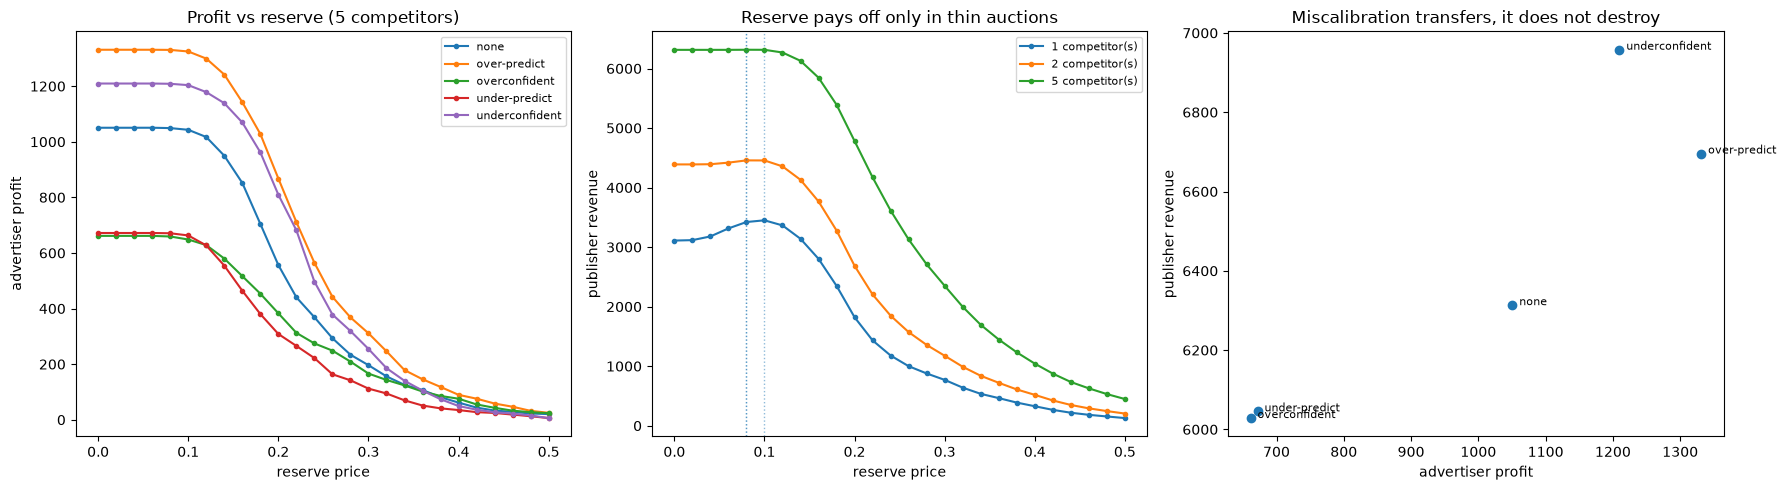

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

thick = sweep[sweep["competitors"] == 5]
for name, group in thick.groupby("scenario"):
    axes[0].plot(group["reserve"], group["profit"], marker="o", markersize=3, label=name)
axes[0].set_xlabel("reserve price")
axes[0].set_ylabel("advertiser profit")
axes[0].set_title("Profit vs reserve (5 competitors)")
axes[0].legend(fontsize=8)

honest = sweep[sweep["scenario"] == "none"]
for n, group in honest.groupby("competitors"):
    axes[1].plot(
        group["reserve"],
        group["publisher_revenue"],
        marker="o",
        markersize=3,
        label=f"{n} competitor(s)",
    )
    peak = group.loc[group["publisher_revenue"].idxmax()]
    axes[1].axvline(peak["reserve"], ls=":", lw=1, alpha=0.5)
axes[1].set_xlabel("reserve price")
axes[1].set_ylabel("publisher revenue")
axes[1].set_title("Reserve pays off only in thin auctions")
axes[1].legend(fontsize=8)

axes[2].scatter(headline["profit"], headline["publisher rev"])
for name, row in headline.iterrows():
    axes[2].annotate(
        name,
        (row["profit"], row["publisher rev"]),
        fontsize=8,
        xytext=(5, 0),
        textcoords="offset points",
    )
axes[2].set_xlabel("advertiser profit")
axes[2].set_ylabel("publisher revenue")
axes[2].set_title("Miscalibration transfers, it does not destroy")

plt.tight_layout()
plt.show()

### What the auction prices

Every row of the headline table has **identical AUC**. They differ only in the
magnitude of their probabilities, and the auction turns that into money.

Three things the numbers say.

**Over-prediction buys the wrong impressions.** A bidder predicting a third too
high wins substantially more auctions, but the extra ones are those where its
true value was below the clearing price. Spend rises, profit falls, effective
CPC rises.

**Under-prediction is quieter and still costs.** Fewer auctions won, so less
profit in absolute terms even though ROI on what it did win looks better. The
cost is opportunity, and it does not show up in any metric the bidder tracks,
which is the asymmetry that makes under-prediction the more dangerous direction:
losing an auction produces no impression, no click, and therefore no evidence
that anything was wrong.

**The money is transferred, not destroyed.** Every scenario that loses
advertiser profit raises publisher revenue. Miscalibration on the buy side is a
wealth transfer to the sell side, which is worth knowing about depending on
which chair you are sitting in.

And on the reserve: it pays off in thin auctions and does almost nothing in
thick ones. With five rivals the runner-up's bid already captures most of the
available surplus, so a floor is redundant; with one, it is the only thing
standing between the publisher and a cheap sale.